In [1]:
# Agglomerative Hierarchical Clustering for Customer Segmentation
# Author: MANIKANDAPRABHU.S
# Objective: Group mall customers into clusters using Annual Income and Spending Score with Agglomerative Hierarchical Clustering.


In [2]:
## 1. Import Libraries
import pandas as pd


In [3]:
## 2. Loading the Dataset
dataset=pd.read_csv("Mall_Customers.csv")

In [4]:
## 3. Exploring the Dataset
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
## 4. Preparing Features
x=dataset.iloc[:,[3,4]].values

Text(0, 0.5, 'Euclidean Distances')

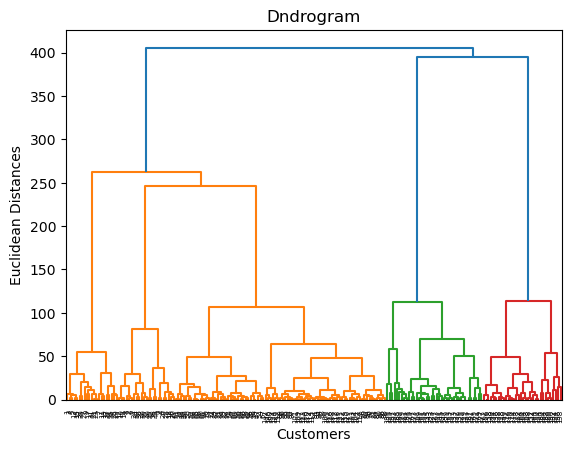

In [6]:
## 5. Creating the Dendrogram
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dndrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')

In [7]:
## 6. Importing the Agglomerative Clustering Model
from sklearn.cluster import AgglomerativeClustering

In [8]:
## 7. Training the Agglomerative Clustering Model
clusmodel=AgglomerativeClustering(n_clusters=5)
label=clusmodel.fit_predict(x)


In [9]:
## 8. Creating the Clustered Dataset
supervised=dataset

In [10]:
## 9. Displaying the Dataset
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
## 10. Adding Cluster Groups
supervised['Cluster_group']=label


In [12]:
## 11. Checking Cluster Labels
label

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [13]:
## 12. Displaying Clustered Data
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,0
197,198,Male,32,126,74,2
198,199,Male,32,137,18,0


In [14]:
## 13. Saving Clustered Data
supervised.to_csv('clusters.csv',index=False)

In [15]:
## 14. Data Visualization
import seaborn as sns

C:\Users\acer\miniconda3\envs\ml\lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


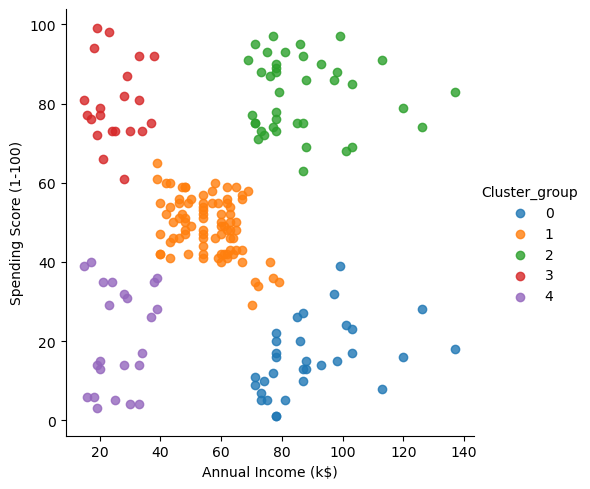

In [16]:
dia=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)

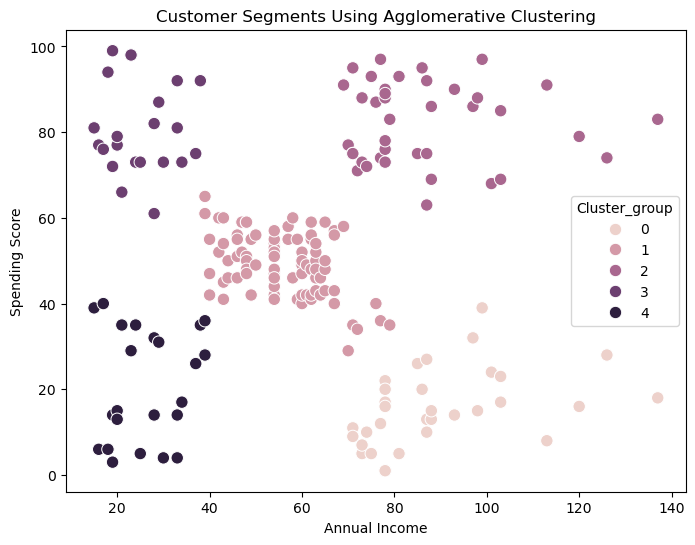

In [17]:
## 15. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=supervised,
    x=supervised.columns[3],
    y=supervised.columns[4],
    hue="Cluster_group",
    s=80
)
plt.title("Customer Segments Using Agglomerative Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


In [18]:
## 16. Saving the Trained Model
import pickle

filename = "Agglomerative_Clustering_Model.sav"
with open(filename, "wb") as file:
    pickle.dump(clusmodel, file)
print("Agglomerative Clustering model saved successfully.")


Agglomerative Clustering model saved successfully.


In [19]:
## 17. Conclusion
# The Agglomerative Clustering model groups customers into five clusters
# using Annual Income and Spending Score. The dendrogram helps identify
# the hierarchical structure of the customer groups.
